In [105]:
import numpy as np
import pysheaf as ps
import scipy
import scipy.linalg
import matplotlib.pyplot as plt
import math

class NetlistSheaf(ps.Sheaf):
    def __init__(self, parts, nets, **kwargs):
        '''
Construct a netlist sheaf using a dictionary of `parts` and `nets`.  
Additional optional arguments accepted as `**kwargs`, so that these can be used as parameters as the sheaf is being built.  

> [!CAUTION]
> This function uses `eval()` to unpack and build Python expressions from strings.  You have been warned; sanitize your input!

Each part is named, and has fields:
* `data_dimension`, 
* `bounds` (optional), 
* `ports`.

The `ports` field is a dictionary naming each port, and associating a string that defines a function for the corresponding restriction map.  

Example:
```
{ "AND2" : { "data_dimension" : 2,
	     "bounds" : "[(0,1)]*2",
	     "ports" : { "IN1" : "lambda x: x[0]",
		       "IN2" : "lambda x: x[1]",
		       "OUT" : "lambda x: x[0]*x[1]" }},
...}
```

Each net is named, and has fields:
* `data_dimension`,
* `bounds` (optional),
* `value` (optional; NB: parsed with `eval()`),
* `optimize` (optional; anything not integer `0` is `True`; default = `True`),
* `constraint` (optional; 'equality' -> `pysheaf.CellConstraintType.EQUALITY`, 'inequality' -> `pysheaf.CellConstraintType.INEQUALITY`, anything else is `pysheaf.CellConstraintType.NONE`)
* `connections`.
Subsequently, `connections` is a list of dictionaries, each one has a `part` and `port` field, which index into the `parts` dictionary above.

```
Example
{
    "A": {
	"data_dimension" : 1,
	"bounds" : "[(0,1)]",
	"connections" : [
	       { "part" : "AND2",
		 "port" : "IN1"}
	   ]
    },
...}
```

> [!TIP]
> The default behavior is that all parts are optimization cells, and that no nets are optimization cells.
        '''
        
        ps.Sheaf.__init__(self)

        self.mNumpyNormType=2

        # First, build the parts (lower level of poset)
        for k,v in parts.items():
            if isinstance(v['data_dimension'],int):
                ddim = v['data_dimension']
            else:
                ddim = eval(v['data_dimension'])
                
            self.AddCell(k,
                         ps.Cell('part',
                                 dataDimension = ddim))
                
            self.GetCell(k).SetDataAssignment(ps.Assignment('part',np.zeros((ddim,))))
            self.GetCell(k).mOptimizationCell = True

        # Next, build the nets (upper level of poset)
        for k,v in nets.items():
            if isinstance(v['data_dimension'],int):
                ddim = v['data_dimension']
            else:
                ddim = eval(v['data_dimension'])

            self.AddCell(k,
                         ps.Cell('net',
                                 dataDimension = ddim))
            
            try:
                self.GetCell(k).SetDataAssignment(ps.Assignment('net',eval(v['value'])))
            except KeyError:
                self.GetCell(k).SetDataAssignment(ps.Assignment('net',np.zeros((ddim,))))

            try:
                self.GetCell(k).mOptimizationCell = (v['optimize']!=0)
            except KeyError:
                pass

            try:
                if v['constraint'] == 'inequality':
                    self.GetCell(k).mConstraintType = ps.CellConstraintType.INEQUALITY
                elif v['constraint'] == 'equality':
                    self.GetCell(k).mConstraintType = ps.CellConstraintType.EQUALITY
            except KeyError:
                pass

            # Connect each part in this net
            for vp in v['connections']:
                part=vp['part']
                port=vp['port']
                self.AddCoface(part,k,
                               ps.Coface('part','net',
                                         eval(parts[part]['ports'][port])))
        return

In [106]:
import csv
import json
import sys
import numpy as np
import scipy.linalg
import networkx as nx
import pysheaf as ps
import matplotlib.pyplot as plt
sys.path.append('/Users/trixiesouthwood/Downloads/research/moose-wolves-sheaf/netlist-sheaf/')
import netlist_sheaf
import numpy.random
import numpy.polynomial
from collections import defaultdict

In [113]:
### Example based upon Figure 4 in
# Thorson et al., "Dynamic structural equation models synthesize ecosystem dynamics constrained by ecological mechanisms", DOI: 10.1111/2041-210X.14289
#
# This model uses the netlist sheaf construction.

import csv
import json
import numpy as np
import scipy.linalg
import pysheaf as ps
import matplotlib.pyplot as plt
import netlist_sheaf
from collections import defaultdict

# Names in the Thorson data disagree with their paper
names_dict={
    "wolves" : "wolves",
    "moose" : "moose"
    }

def lag_fcn(npts,ar,x):
    '''Convenience function for building lag matrices'''
    if ar:
        return scipy.linalg.toeplitz(np.concatenate(([0],x[0:ar],np.zeros((npts-ar-1,)))),np.zeros((npts,)))
    else: # Disable autoregression
        return np.eye(npts)

# Load the sheaf structure
parts=json.load(open('/Users/trixiesouthwood/Downloads/research/two_way_parts_copy.json'))
nets=json.load(open('/Users/trixiesouthwood/Downloads/research/two_way_nets_copy.json'))

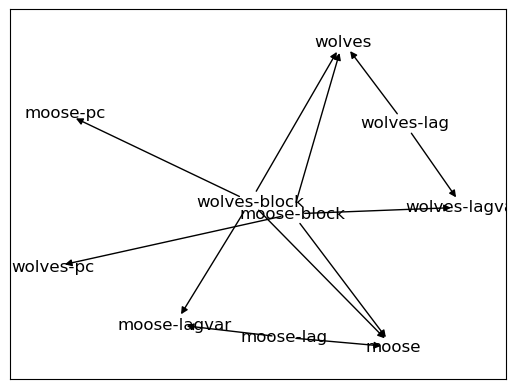

In [114]:
from enum import Enum

# Temporary patch for missing enum
class CellConstraintType(Enum):
    EQUALITY = 0
    INEQUALITY = 1

ps.CellConstraintType = CellConstraintType

startyear = 1959
npts = 61
ar = 0
shf = netlist_sheaf.NetlistSheaf(parts,nets,npts=npts,ar=ar,lag_fcn=lag_fcn)

pos=nx.layout.spring_layout(shf)
nx.draw_networkx_labels(shf,pos)
nx.draw_networkx_edges(shf,pos)
plt.show()

# Load the data; adding in new cells to house the known values
measurements = defaultdict(list)
with open('/Users/trixiesouthwood/Downloads/research/moose-wolves-sheaf/log_isle_royal_data.csv') as fp:
    reader = csv.DictReader(fp, delimiter = ',')
    idx = 0
    for row in reader:
        for data_name,sheaf_name in names_dict.items():
            if row[data_name] != 'NA':
                year = startyear+idx
                datum = str(year) + "-" + sheaf_name
                value = float(row[data_name])

                measurements[sheaf_name].append((year,value))
                
                shf.AddCell(datum, ps.Cell('datum',dataDimension=1))
                shf.GetCell(datum).SetDataAssignment(ps.Assignment('datum', np.array([value])))
                shf.AddCoface(sheaf_name,datum,
                              ps.Coface('net','datum', lambda x,idx=idx : x[idx] ))
        
        idx = idx + 1



In [132]:
star_consistency = []
local_CR = []
total_CR = [] 

for c in shf.GetCellIndexList():
    shf.MaximallyExtendCell(c)

print('===')
print("Consistency radius before optimization: {}".format(shf.ComputeConsistencyRadius()))

print('Optimizing...')
shf.FuseAssignment()

print("Consistency radius after optimization: {}".format(shf.ComputeConsistencyRadius()))

print('===')
print("Path coefficients:") 
print('---')

for c in shf.GetCellIndexList():
    if "-pc" in c:
        print("{} : {}".format(c,shf.GetCell(c).mDataAssignment.mValue))

print('===')
print("Offsets:")
print('---')

for c in shf.GetCellIndexList():
    if c == 'moose-block':
        print("{} : {}".format(c,shf.GetCell(c).mDataAssignment.mValue[0:2]))
    elif "-block" in c:
        print("{} : {}".format(c,shf.GetCell(c).mDataAssignment.mValue[0]))

print('===')
print("Autoregressive cofficients:")
print('---')

for data_name,sheaf_name in names_dict.items():
    try:
        print("{} : {}".format(sheaf_name,shf.GetCell(sheaf_name + "-lag").mDataAssignment.mValue[0:ar]))
    except KeyError:
        pass


print('')
print('==========')
print('All stalks')
print('---')
for c in shf.GetCellIndexList():
    print("{} : Star local consistency radius: {}".format(c,shf.ComputeStarLocalConsistencyRadius(c)))
    print("- -")
    print("{} : {}".format(c,shf.GetCell(c).mDataAssignment.mValue))
    star_consistency.append(shf.ComputeStarLocalConsistencyRadius(c))
 #   local_CR.append(shf.ComputeLocalConsistencyRadius(c))
  #  total_CR.append(shf.ComputeConsistencyRadius(c))
        
years=[startyear + year for year in range(npts)]


===
Consistency radius before optimization: 4.925548505414726
Optimizing...
Consistency radius after optimization: 4.925548443138828
===
Path coefficients:
---
moose-pc : [-2.98665589]
wolves-pc : [-0.29863544]
===
Offsets:
---
wolves-block : 23.33038848671104
moose-block : [ 7.70453975 -0.29749349]
===
Autoregressive cofficients:
---
wolves : []
moose : []

All stalks
---
wolves-block : Star local consistency radius: 3.580606973477463
- -
wolves-block : [23.33038849 -2.98615383  6.7513028   6.72822852  6.729851    6.71795814
  6.76276686  6.68908509  6.6695922   6.69628001  6.76243031  6.77396289
  6.87348118  6.85689718  6.83941978  6.80337357  6.78815856  6.71097258
  6.62153235  6.59351529  6.65689072  6.59529732  6.57552177  6.52117654
  6.67050653  6.89898375  6.75827996  6.75786644  6.7895373   6.82218619
  6.8920098   6.98495917  6.99838286  6.93684842  7.0176843   7.03172843
  7.01347627  6.94734299  6.97084451  6.89009849  6.75454951  6.91812969
  6.75365222  6.71348092  6.84

In [117]:
year = list(range(1959, 2020, 1))

In [122]:
# why is wolves block 63 values when there are only 61 years 
# what are the first two values in the wolves_block and moose_block 

wolves_block = np.exp(np.array([23.33038999, -2.98614315, 6.75130271, 6.72822852, 6.72985129, 6.71795826,
6.76276678, 6.68908503, 6.66959245, 6.69628011, 6.7624302, 6.77396327,
6.87348113, 6.85689711, 6.83941986, 6.80337379, 6.78815866, 6.71097329,
6.62153259, 6.59351545, 6.65689091, 6.59529655, 6.5755217, 6.52117616,
6.67050746, 6.89898355, 6.75828028, 6.75786642, 6.78953729, 6.82218621,
6.89200956, 6.98495912, 6.99838235, 6.93684833, 7.01768433, 7.03172826,
7.01347595, 6.94734278, 6.97084431, 6.89009886, 6.75454941, 6.91812989,
6.75365134, 6.71348109, 6.84854288, 6.87962539, 6.82413813, 6.67783072,
6.63111471, 6.61066132, 6.69954507, 6.73088142, 6.69555021, 6.76056304,
6.81283776, 7.02613616, 7.09052577, 7.06364974, 7.41039637, 7.53523116,
7.55868456, 7.54928806, 6.9870160]))

wolves_block_edited = np.exp(np.array([6.75130271, 6.72822852, 6.72985129, 6.71795826,
6.76276678, 6.68908503, 6.66959245, 6.69628011, 6.7624302, 6.77396327,
6.87348113, 6.85689711, 6.83941986, 6.80337379, 6.78815866, 6.71097329,
6.62153259, 6.59351545, 6.65689091, 6.59529655, 6.5755217, 6.52117616,
6.67050746, 6.89898355, 6.75828028, 6.75786642, 6.78953729, 6.82218621,
6.89200956, 6.98495912, 6.99838235, 6.93684833, 7.01768433, 7.03172826,
7.01347595, 6.94734278, 6.97084431, 6.89009886, 6.75454941, 6.91812989,
6.75365134, 6.71348109, 6.84854288, 6.87962539, 6.82413813, 6.67783072,
6.63111471, 6.61066132, 6.69954507, 6.73088142, 6.69555021, 6.76056304,
6.81283776, 7.02613616, 7.09052577, 7.06364974, 7.41039637, 7.53523116,
7.55868456, 7.54928806, 6.9870160]))

moose_block = np.exp(np.array([7.70453807, -0.29749755, 3.12613589, 3.20296147, 3.19943856, 3.23745272,
3.1006928, 3.33403147, 3.39696605, 3.3180413, 3.12680206, 3.10137721,
2.81175925, 2.86378575, 2.93039083, 3.04692368, 3.09266534, 3.33182985,
3.60415282, 3.68537438, 3.47678023, 3.65586928, 3.71935995, 3.87990678,
3.41348349, 2.70373561, 3.14803483, 3.15931234, 3.06652501, 2.96878937,
2.75442021, 2.47238511, 2.44182559, 2.63773149, 2.39919131, 2.36783568,
2.42935495, 2.64660258, 2.57902523, 2.84291793, 3.16686375, 2.66148336,
3.17953997, 3.30876627, 2.89621297, 2.79805004, 2.95087713, 3.3877136,
3.50065064, 3.54616856, 3.25437657, 3.20909426, 3.2997082, 3.09221024,
2.93104812, 2.30462759, 2.13018865, 2.22079966, 1.15996161, 0.77456734,
0.72532553, 0.74342827, 2.52606107]))

moose_block_edited = np.exp(np.array([3.12613589, 3.20296147, 3.19943856, 3.23745272,
3.1006928, 3.33403147, 3.39696605, 3.3180413, 3.12680206, 3.10137721,
2.81175925, 2.86378575, 2.93039083, 3.04692368, 3.09266534, 3.33182985,
3.60415282, 3.68537438, 3.47678023, 3.65586928, 3.71935995, 3.87990678,
3.41348349, 2.70373561, 3.14803483, 3.15931234, 3.06652501, 2.96878937,
2.75442021, 2.47238511, 2.44182559, 2.63773149, 2.39919131, 2.36783568,
2.42935495, 2.64660258, 2.57902523, 2.84291793, 3.16686375, 2.66148336,
3.17953997, 3.30876627, 2.89621297, 2.79805004, 2.95087713, 3.3877136,
3.50065064, 3.54616856, 3.25437657, 3.20909426, 3.2997082, 3.09221024,
2.93104812, 2.30462759, 2.13018865, 2.22079966, 1.15996161, 0.77456734,
0.72532553, 0.74342827, 2.52606107]))


moose_lag = np.exp(np.array([6.49608633, 6.51197382, 6.52030122, 6.52173191, 6.55795627, 6.54711582,
6.55054263, 6.58539141, 6.69604423, 6.75738078, 6.91442825, 6.90926614,
6.96974687, 6.98132771, 6.96196982, 6.92249637, 6.85283382, 6.80594287,
6.7676742, 6.67660502, 6.67552919, 6.60536379, 6.65635296, 6.76631953,
6.73848941, 6.79938728, 6.84166083, 6.87727372, 6.92517032, 7.00206027,
7.07488457, 7.07135137, 7.17832812, 7.25392223, 7.27376369, 7.3120731,
7.34914771, 7.38201081, 6.78159534, 6.86885143, 6.83771747, 6.83848652,
6.94380755, 6.94761657, 6.81226224, 6.6473091, 6.44506131, 6.33486567,
6.28815741, 6.5916068, 6.46348061, 6.47055373, 6.49884032, 6.8008248,
6.97431373, 7.00315247, 7.2528452, 7.32906547, 7.45320197, 7.40431919,
7.34159909]))

wolves_lag = np.exp(np.array([3.05816319, 3.14473457, 3.14295987, 3.18423109, 3.04598998, 3.29422209,
3.362754, 3.28644635, 3.10791868, 3.09485626, 2.82291206, 2.87754407,
2.96399861, 3.09192525, 3.13640336, 3.3839902, 3.65942345, 3.7355954,
3.50180181, 3.67223684, 3.74020887, 3.89573167, 3.40662636, 2.67051313,
3.14140296, 3.16882035, 3.07896967, 2.98256086, 2.76393323, 2.47968624,
2.46469488, 2.67430534, 2.44422638, 2.42892628, 2.49980556, 2.74304322,
2.67941758, 2.97100107, 3.17241818, 2.65001996, 3.19953541, 3.33854573,
2.92118112, 2.81628552, 2.9474535, 3.3764911, 3.44826992, 3.47056231,
3.1451222, 3.17098886, 3.23624065, 3.01566185, 2.84928557, 2.24989226,
2.1049567, 2.20899611, 1.12990908, 0.73528605, 0.71128656, 0.7200202,
2.62058884]))

moose = np.exp(np.array([6.57803333, 6.58247672, 6.58882448, 6.58661266, 6.62377252, 6.59559255,
6.5927877, 6.62434541, 6.71907759, 6.76432853, 6.90070871, 6.8924648,
6.92960725, 6.92741531, 6.90980021, 6.86085466, 6.78798275, 6.74779066,
6.73897142, 6.6586796, 6.65266679, 6.58879302, 6.66589798, 6.80572062,
6.74709435, 6.7891017, 6.82714811, 6.86072367, 6.91347746, 6.99228756,
7.04643959, 7.02671753, 7.12292865, 7.17924001, 7.18755445, 7.19597928,
7.2280003, 7.22834441, 6.77580438, 6.88175894, 6.81443164, 6.80354776,
6.91405963, 6.92528985, 6.8164599, 6.66137564, 6.50939299, 6.42818378,
6.42049393, 6.63809207, 6.53938604, 6.56302266, 6.59733934, 6.86492852,
7.00224081, 7.01512578, 7.28307338, 7.37162308, 7.46521133, 7.4287672,
7.22686632]))

wolves = np.exp(np.array([3.08726302, 3.16888116, 3.16658564, 3.20622406, 3.06930491, 3.30977137,
3.37573342, 3.298567, 3.11525714, 3.09736897, 2.81836583, 2.87157165,
2.9493135, 3.07253413, 3.11648472, 3.35981346, 3.63309015, 3.71046895,
3.48813274, 3.6616519, 3.72740015, 3.88421571, 3.40750483, 2.68571834,
3.14301019, 3.16375719, 3.07276891, 2.97623827, 2.76039477, 2.4775638,
2.45648075, 2.65939768, 2.4265801, 2.40451812, 2.47115286, 2.70272536,
2.63681949, 2.91549862, 3.16891242, 2.65601039, 3.18962716, 3.32372328,
2.91035924, 2.80867561, 2.9487291, 3.37943287, 3.46873304, 3.50075922,
3.19201202, 3.18586196, 3.26171555, 3.04826054, 2.88440467, 2.27594224,
2.11888594, 2.21731919, 1.15104589, 0.76171045, 0.72519865, 0.739987,
2.5806931]))

moose_lagvar = np.exp(np.array([6.58447623, 6.54627341, 6.68247381, 6.63939867, 6.65165078, 6.60527986,
6.62008965, 6.66211143, 6.74525429, 6.76088704, 6.90580289, 6.86151625,
6.88867994, 6.82502953, 6.81155664, 6.83759044, 6.69392822, 6.65011093,
6.75375273, 6.61940946, 6.61865792, 6.54631183, 6.65834825, 6.89441667,
6.74350508, 6.78273619, 6.82269769, 6.84518796, 6.91264504, 6.99406571,
7.04576197, 6.98323103, 7.12075433, 7.20560275, 7.0975867, 7.14567492,
7.19449554, 7.00740203, 6.76183985, 6.90501294, 6.77304123, 6.80695749,
6.88933729, 6.89842795, 6.81495813, 6.6635509, 6.5031957, 6.48181254,
6.42235592, 6.65094304, 6.5893836, 6.63974791, 6.52041594, 7.0074753,
7.0652677, 7.0539722, 7.33498126, 7.46812077, 7.53249198, 7.44870536,
7.29292384]))

wolves_lagvar = np.exp(np.array([3.12372843, 3.17569439, 3.17998096, 3.23377795, 3.09839979, 3.32883375,
3.38906608, 3.3121595, 3.12209092, 3.09777624, 2.81417305, 2.86781925,
2.93330619, 3.06951355, 3.12285672, 3.37966304, 3.65736577, 3.72500219,
3.48478633, 3.65991439, 3.72997076, 3.88018249, 3.40667839, 2.67583214,
3.1418102, 3.16080974, 3.06983218, 2.97152906, 2.75886537, 2.47650523,
2.44258933, 2.66502223, 2.40371602, 2.38351159, 2.49518856, 2.73425682,
2.64474649, 2.95696347, 3.16740983, 2.66126789, 3.18645439, 3.32247963,
2.89670361, 2.80760139, 2.94912563, 3.37830393, 3.49932442, 3.5095471,
3.24009073, 3.18471473, 3.29714213, 3.0521593, 2.86055701, 2.26481944,
2.1131141, 2.22013713, 1.15857026, 0.76870616, 0.72206686, 0.74155132,
2.5420295]))


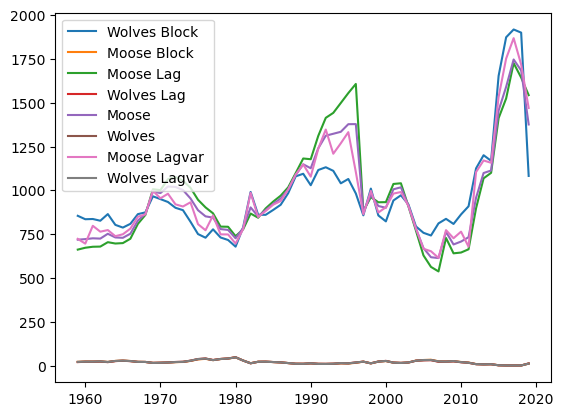

In [123]:
plt.plot(year, wolves_block_edited, label = "Wolves Block")
plt.plot(year, moose_block_edited, label = "Moose Block")
plt.plot(year, moose_lag, label = "Moose Lag")
plt.plot(year, wolves_lag, label = "Wolves Lag")
plt.plot(year, moose, label = "Moose")
plt.plot(year, wolves, label = "Wolves")
plt.plot(year, moose_lagvar, label = "Moose Lagvar")
plt.plot(year, wolves_lagvar, label = "Wolves Lagvar")
plt.legend()

Text(0.5, 1.0, 'Wolves Parts of Two Way Sheaf')

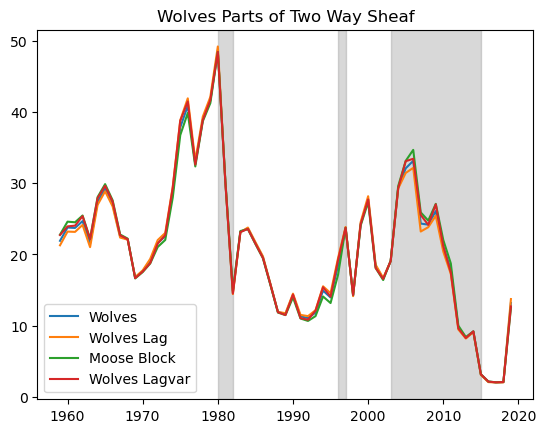

In [256]:
plt.plot(year, wolves, label = "Wolves")
plt.plot(year, wolves_lag, label = "Wolves Lag")
# plt.plot(year, wolves_block_edited, label = "Wolves Block")
plt.plot(year, moose_block_edited, label = "Moose Block")
plt.plot(year, wolves_lagvar, label = "Wolves Lagvar")
plt.axvspan(xmin=1980, xmax=1982, color='grey', alpha=0.3)
plt.axvspan(xmin=1996, xmax=1997, color='grey', alpha=0.3)
plt.axvspan(xmin=2003, xmax=2015, color='grey', alpha=0.3)
plt.legend()
plt.title("Wolves Parts of Two Way Sheaf")

Text(0.5, 1.0, 'Moose Parts of Two Way Sheaf')

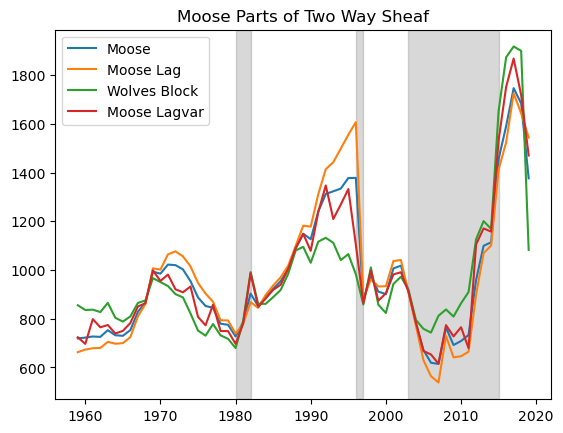

In [255]:
plt.plot(year, moose, label = "Moose")
plt.plot(year, moose_lag, label = "Moose Lag")
# plt.plot(year, moose_block_edited, label = "Moose Block")
plt.plot(year, wolves_block_edited, label = "Wolves Block")
plt.plot(year, moose_lagvar, label = "Moose Lagvar")
plt.axvspan(xmin=1980, xmax=1982, color='grey', alpha=0.3)
plt.axvspan(xmin=1996, xmax=1997, color='grey', alpha=0.3)
plt.axvspan(xmin=2003, xmax=2015, color='grey', alpha=0.3)
plt.legend()
plt.title("Moose Parts of Two Way Sheaf")

### Star Consistency Radii

In [149]:
len(star_consistency)

#wolves-block : Star local consistency radius: 3.580606973477463
#moose-block : Star local consistency radius: 3.494410943952684
#moose-lag : Star local consistency radius: 2.2224815159381883
#wolves-lag : Star local consistency radius: 0.6894576441429452
#moose : Star local consistency radius: 1.6378503500046335
#wolves : Star local consistency radius: 0.5196710853676557
#moose-pc : Star local consistency radius: 0.0
#wolves-pc : Star local consistency radius: 0.0
#moose-lagvar : Star local consistency radius: 0.0
#wolves-lagvar : Star local consistency radius: 0.0
# 61 0s + 61 0s 
# = 132 

132

In [164]:
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
# 0 = size 100
# 0 - 1 = size 300 400
# 1 - 2 = size 500 700
# 2 - 3 = size 700 1000
# 3 - 4 = size 900 1300


# 0 = size 100
# 0 - 2 = size 700
# 2 - 4 = size 1300



#wolves-block : Star local consistency radius: 3.580606973477463
#moose-block : Star local consistency radius: 3.494410943952684
#moose-lag : Star local consistency radius: 2.2224815159381883
#wolves-lag : Star local consistency radius: 0.6894576441429452
#moose : Star local consistency radius: 1.6378503500046335
#wolves : Star local consistency radius: 0.5196710853676557
#moose-pc : Star local consistency radius: 0.0
#wolves-pc : Star local consistency radius: 0.0
#moose-lagvar : Star local consistency radius: 0.0
#wolves-lagvar : Star local consistency radius: 0.0

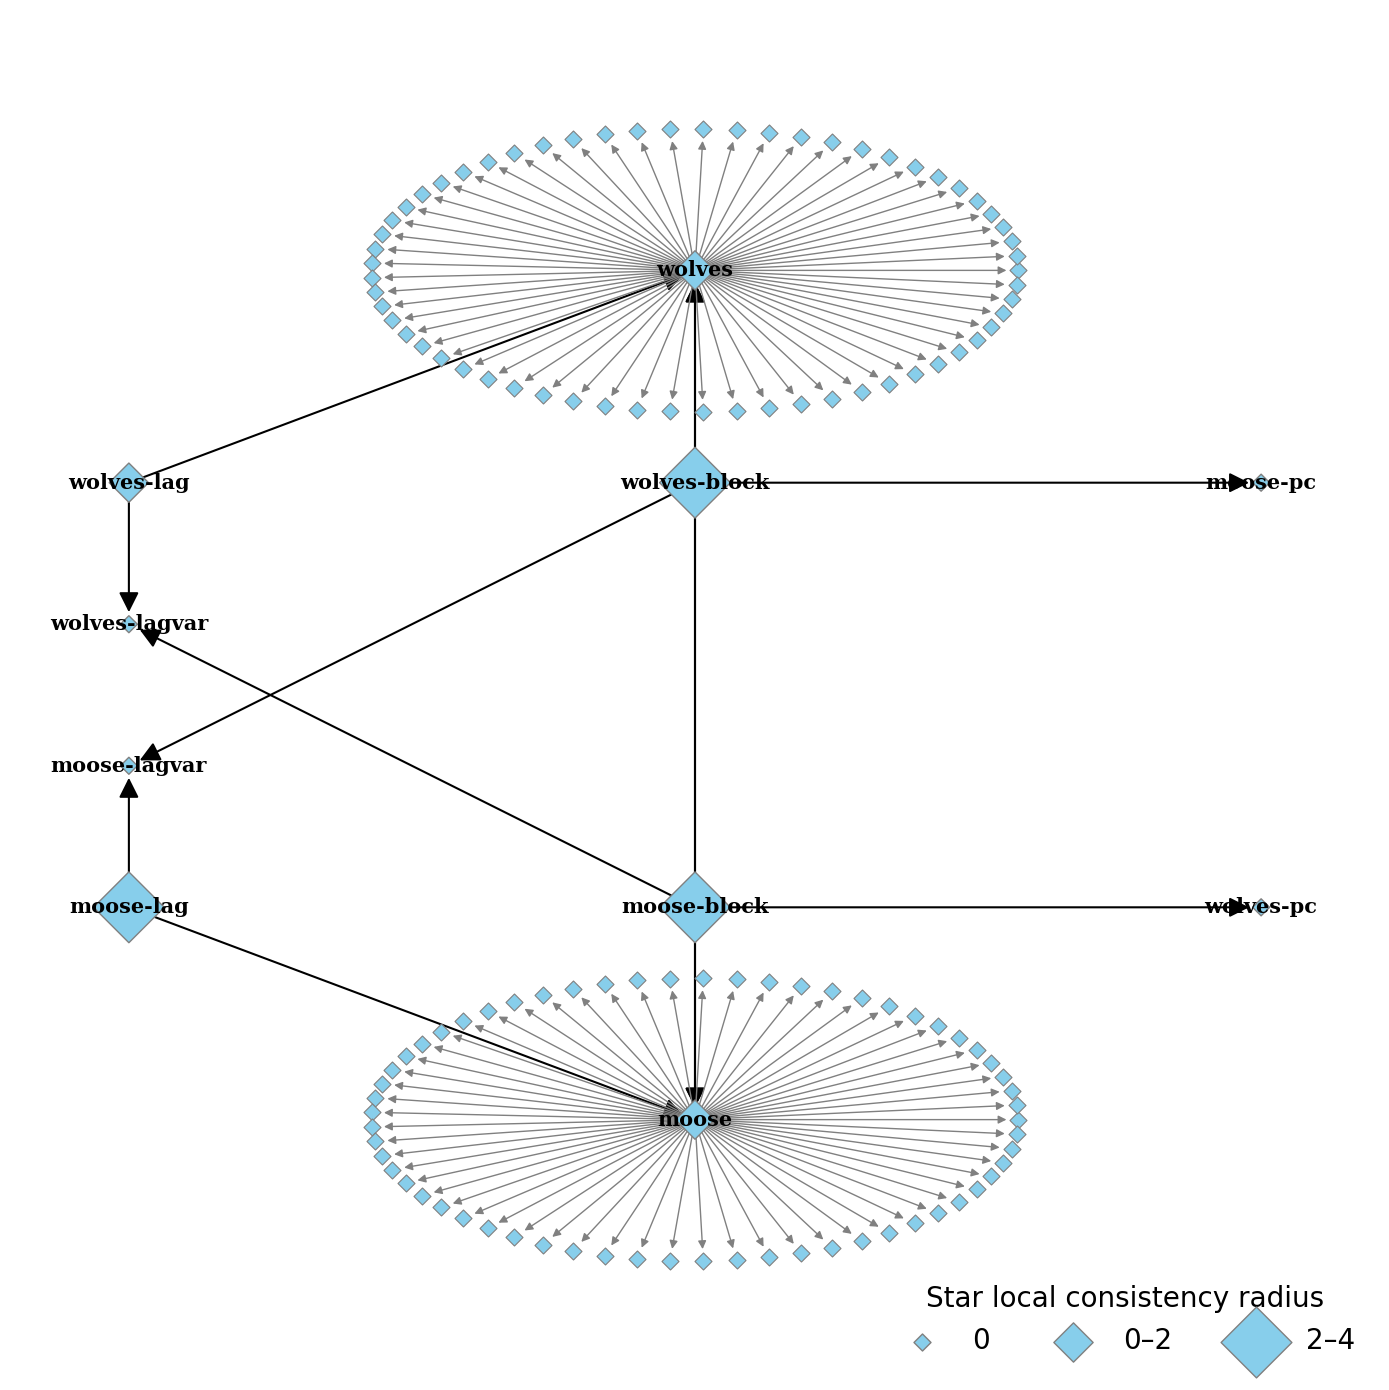

In [253]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

G = nx.DiGraph()

main_nodes = ["wolves-pc", "moose-block", "moose", "moose-lag", "moose-lagvar",
    "wolves-block", "moose-pc", "wolves", "wolves-lag", "wolves-lagvar"]

main_sizes = [75, 1300, 400, 1300, 75, 1300, 75, 400, 400, 75]

size_dict = dict(zip(main_nodes, main_sizes))

G.add_nodes_from(main_nodes)

extra_nodes = [f"extra_{i}" for i in range(122)]
G.add_nodes_from(extra_nodes)

G.add_edges_from([
    ("moose-block", "wolves-pc"),
    ("moose-block", "moose"),
    ("moose-lag", "moose"),
    ("moose-lag", "moose-lagvar"),
    ("wolves-block", "moose-lagvar"),
    ("wolves-block", "moose-pc"),
    ("wolves-block", "moose"),
    ("wolves-block", "wolves"),
    ("wolves-lag", "wolves"),
    ("moose-block", "wolves"),
    ("wolves-lag", "wolves-lagvar"),
    ("moose-block", "wolves-lagvar")
])

pos = {
    "wolves": (0, 1.2),
    "wolves-block": (0, 0.6),
    "moose-pc": (0.7, 0.6),
    "wolves-lag": (-0.7, 0.6),
    "wolves-lagvar": (-0.7, 0.2),

    "moose": (0, -1.2),
    "moose-block": (0, -0.6),
    "wolves-pc": (0.7, -0.6),
    "moose-lag": (-0.7, -0.6),
    "moose-lagvar": (-0.7, -0.2),
}


moose_extra = extra_nodes[:61]
wolves_extra = extra_nodes[61:]

def scatter_around(center_node, nodes, radius=0.4):
    cx, cy = pos[center_node]
    angles = np.linspace(0, 2*np.pi, len(nodes), endpoint=False)
    for node, angle in zip(nodes, angles):
        pos[node] = (
            cx + radius * np.cos(angle),
            cy + radius * np.sin(angle)
        )

scatter_around("moose", moose_extra)
scatter_around("wolves", wolves_extra)

plt.figure(figsize=(14, 14))

nx.draw_networkx_nodes(
    G, pos,
    nodelist=extra_nodes,
    node_size=75,
    node_shape='D',
    node_color="skyblue",
    edgecolors="gray",
    linewidths=0.8
)

nx.draw_networkx_nodes(
    G, pos,
    nodelist=main_nodes,
    node_size=[size_dict[n] for n in main_nodes],
    node_shape='D',
    node_color="skyblue",
    edgecolors="gray"
)

nx.draw_networkx_edges(
    G, pos,
    edge_color="black",
    alpha=1,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=30,
    width=1.5
)

edges_from_wolves_extra = [("wolves", n) for n in wolves_extra]
edges_from_moose_extra = [("moose", n) for n in moose_extra]

nx.draw_networkx_edges(
    G, pos,
    edgelist=edges_from_wolves_extra + edges_from_moose_extra,
    edge_color="gray",
    arrows=True,
    arrowstyle='-|>',
    arrowsize=12,
    width=1
)

nx.draw_networkx_labels(
    G, pos,
    labels={n: n for n in main_nodes},
    font_size=15,
    font_family="serif", 
    font_weight="bold"
)


legend_sizes = [75, 400, 1300]
legend_labels = ["0", "0–2", "2–4"]

handles = [plt.scatter([], [], s=s, color='skyblue', edgecolors= "gray", marker='D')
    for s in legend_sizes]

plt.legend(handles, legend_labels, ncols = 3, prop={'size': 20},
    title="Star local consistency radius",
    loc='lower right', frameon=False, title_fontsize=20)

plt.axis("off")
plt.tight_layout()
plt.show()